
# 🌆 Exploratory Data Visualization of Real-Time Air Quality Metrics Using Python with Dirty Sensor Data

This notebook presents a detailed explanation and summary of air quality data collected from multiple Indian cities.  
It focuses on understanding the **data cleaning process**, **statistical exploration**, and **key insights** derived from the analysis.

---


## 🏁 Introduction

Air pollution is one of the major environmental challenges in urban India.  
This dataset, `city_day.csv`, contains daily air quality observations for various cities, including pollutant concentrations such as **PM2.5, PM10, NO2, SO2, CO, and O3**, and the **Air Quality Index (AQI)**.

Pollutants with the strongest evidence for public health concern include particulate matter (PM), carbon monoxide (CO), ozone (O 3), nitrogen dioxide (NO 2) and sulfur dioxide (SO 2). Health problems can occur as a result of both short- and long-term exposure to these various pollutants.
PM10 (particles with a diameter of 10 micrometres or less): these particles are small enough to pass through the throat and nose and enter the lungs. PM2.5 (particles with a diameter of 2.5 micrometres or less): these particles are so small they can get deep into the lungs and into the bloodstream. Once inhaled, these particles can affect the heart and lungs and cause serious health effects.

Aim of project:
- To analyze and visualize real-time air quality data using Python in order to identify pollution trends, detect data inconsistencies, and compare pollutant levels across locations.  
- The project focuses on handling unclean environmental data and transforming it into meaningful insights through visual representations.

## 1)🧩  Install / Import libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime

## 2)🌐 Fetch data from OpenAQ (India)

In [15]:
df=pd.read_csv(r"C:\Users\admin\OneDrive\Documents\Project\city_day.csv")


## 🧹 Data Cleaning and Preparation

The raw dataset contained missing values, duplicates, and unformatted column names.  
The following preprocessing steps were performed:

1. **Column Formatting:** All column names were standardized to uppercase and underscores.  
2. **Handling Missing Values:**
   - Numeric columns were filled with the **median**.
   - Categorical columns were filled with the **mode**.
3. **Duplicate Removal:** Identical rows were removed to ensure data integrity.
4. **Date Conversion:** The `Date` column was converted to datetime format.
5. **Derived Features:**
   - Extracted `year` and `month` from `date`.
   - Created a new feature `avg_pollution` as the mean of all key pollutants (`PM2.5`, `PM10`, `NO2`, `SO2`, `CO`, `O3`).

After cleaning, the dataset was ready for exploratory analysis.

In [16]:
# 🧹 Dataset Cleaning and Transformation Script

# 1 View basic info
print("Initial shape:", df.shape)
df.info()
df.describe()
df.isnull().sum()
df.head()


Initial shape: (29531, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [17]:
# 2️⃣ Handle Missing Data

print("\nMissing values per column:\n", df.isnull().sum())

# Fill numeric columns with median
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 3️⃣ Remove Duplicates

before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]
print(f"\nRemoved {before - after} duplicate rows")

# 4️⃣ Formatting

# Strip whitespace and convert column names to Uppercase
df.columns = df.columns.str.strip().str.upper().str.replace(' ', '_')

# Convert 'date' column to datetime (if exists)
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Standardize text fields
if 'city' in df.columns:
    df['city'] = df['city'].str.title().str.strip()

# 5️⃣ Derived Features

# Extract year, month, and day from date
if 'date' in df.columns:
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day

# Derive pollution index
if {'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3'}.issubset(df.columns):
    df['avg_pollution'] = df[['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']].mean(axis=1)

# 6️⃣ Transformation

# Normalize numeric data 
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# 7️ Save the cleaned dataset

print("\nCleaned dataset info:")
print(df.info())
print(df.head())

df.to_csv("city_day_cleaned.csv", index=False)
print("\n✅ Cleaned dataset saved as 'city_day_cleaned.csv'")



Missing values per column:
 City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Removed 0 duplicate rows

Cleaned dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CITY           29531 non-null  object 
 1   DATE           29531 non-null  object 
 2   PM2.5          29531 non-null  float64
 3   PM10           29531 non-null  float64
 4   NO             29531 non-null  float64
 5   NO2            29531 non-null  float64
 6   NOX            29531 non-null  float64
 7   NH3            29531 non-null  float64
 8   CO             29531 non-null  floa

C:\Users\admin\AppData\Local\Temp\ipykernel_2892\2243015205.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\admin\AppData\Local\Temp\ipykernel_2892\2243015205.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl


✅ Cleaned dataset saved as 'city_day_cleaned.csv'


## 📊 Univariate Analysis

Univariate analysis involves studying **one variable at a time** to understand its characteristics.

### Objectives:
- To explore the **distribution** of numeric variables (e.g., PM2.5, PM10).  
- To identify the **most frequent categories** (e.g., cities, AQI buckets).  
- To understand **central tendencies** (mean, median) and **spread** (variance, range).

### Findings:
- **PM2.5** and **PM10** showed a wide range of values with a right-skewed distribution.  
- **AQI buckets** indicated that most days fall under *Moderate* and *Poor* categories.  
- Some cities consistently recorded higher average pollutant levels than others.

===== UNIVARIATE ANALYSIS =====

             CITY        DATE         PM2.5          PM10            NO  \
count       29531       29531  29531.000000  29531.000000  29531.000000   
unique         26        2009           NaN           NaN           NaN   
top     Ahmedabad  2020-06-26           NaN           NaN           NaN   
freq         2009          26           NaN           NaN           NaN   
mean          NaN         NaN      0.067868      0.109650      0.042550   
std           NaN         NaN      0.062959      0.072325      0.055051   
min           NaN         NaN      0.000000      0.000000      0.000000   
25%           NaN         NaN      0.033802      0.079306      0.015845   
50%           NaN         NaN      0.051087      0.095671      0.025265   
75%           NaN         NaN      0.076225      0.111871      0.044924   
max           NaN         NaN      1.000000      1.000000      1.000000   

                 NO2           NOX           NH3            CO    

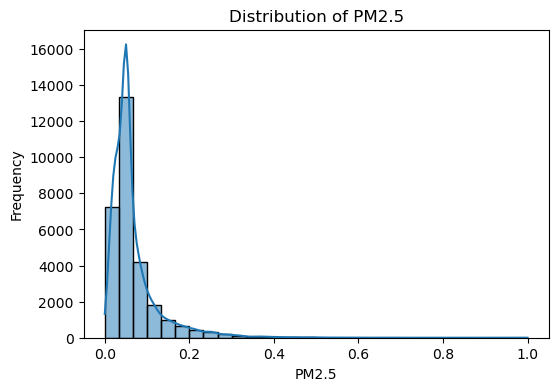

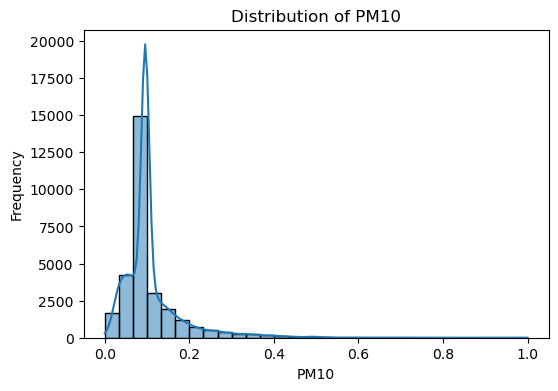

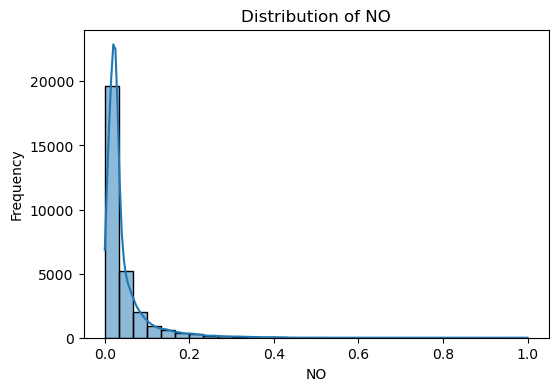

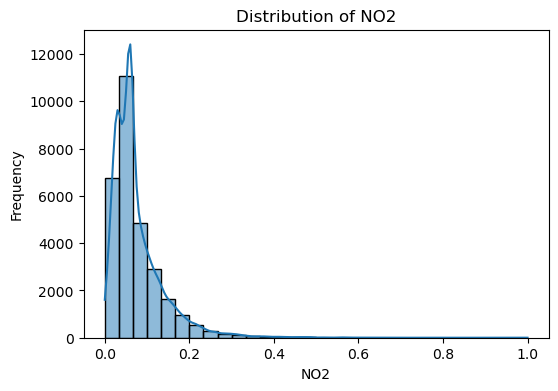

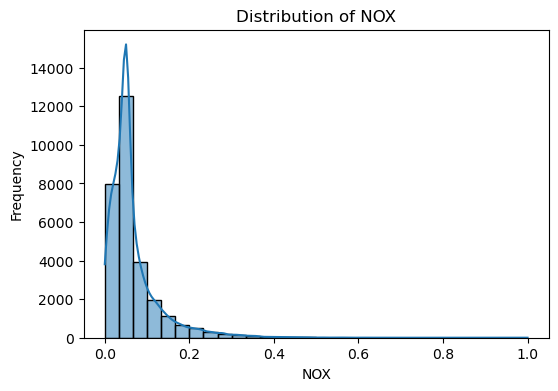

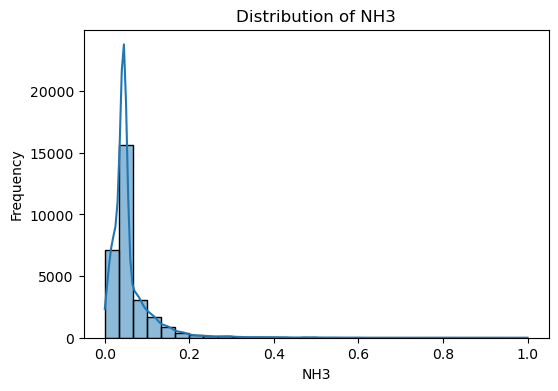

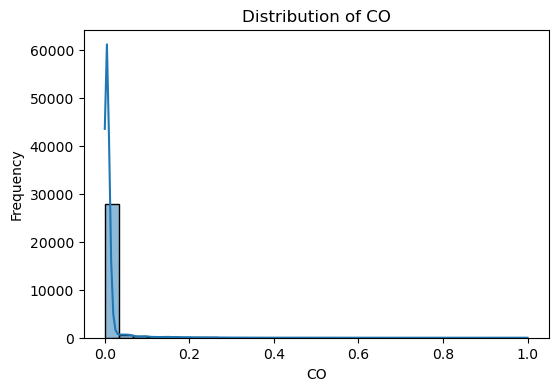

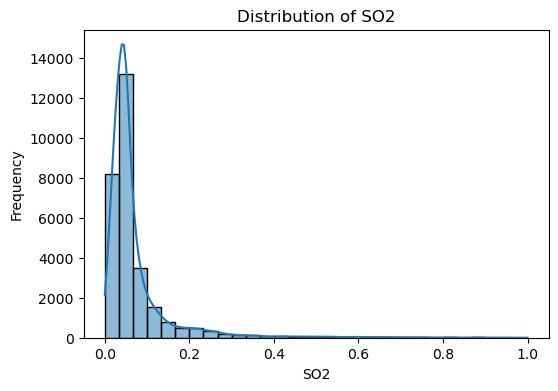

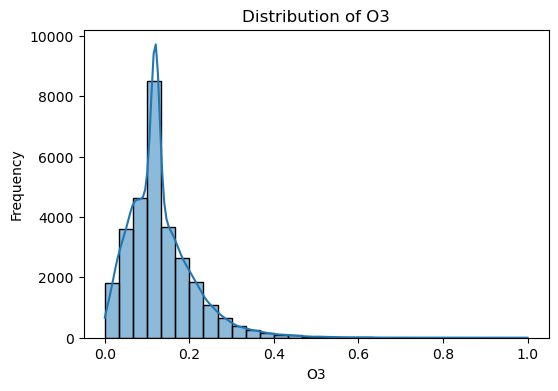

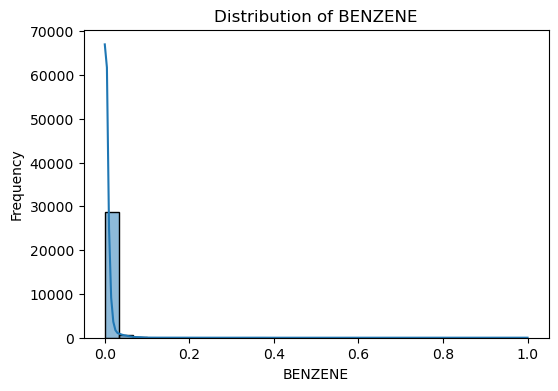

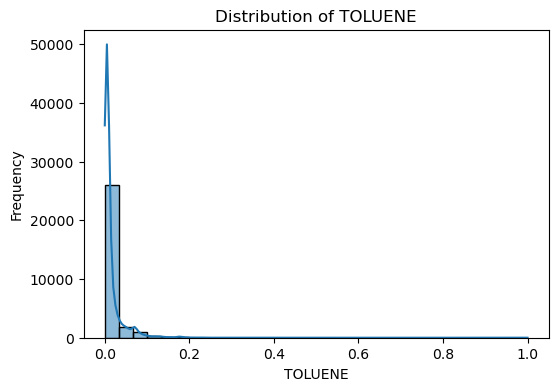

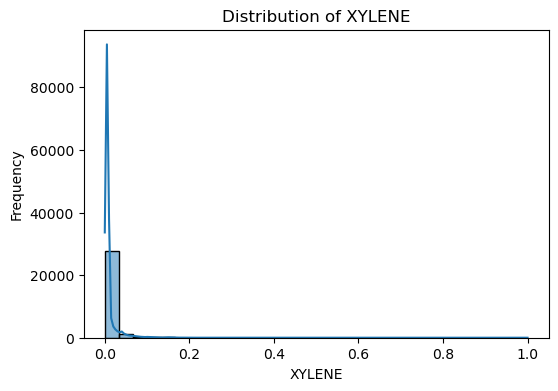

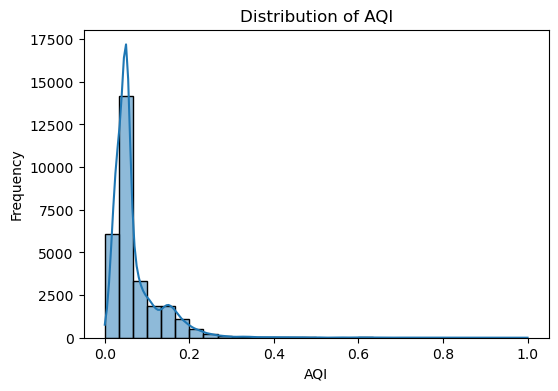

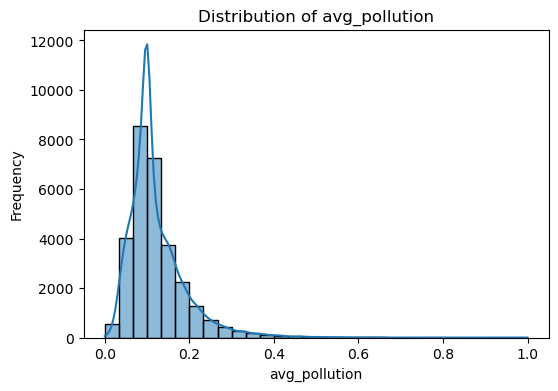

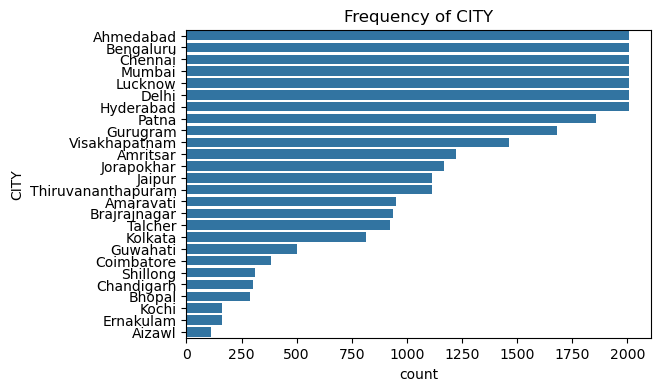

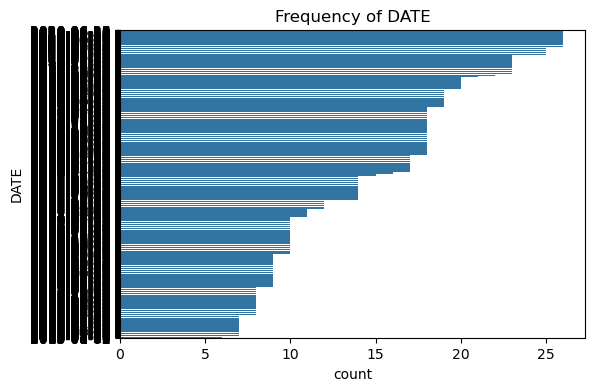

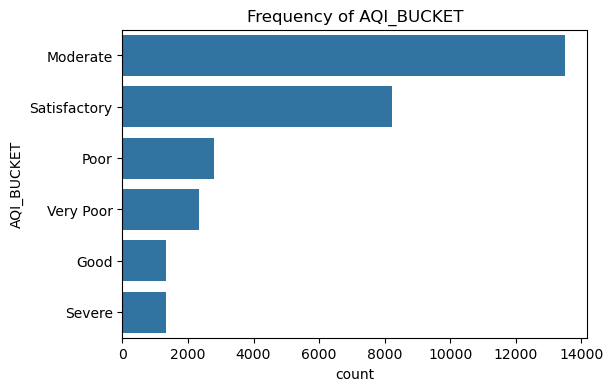

In [18]:
# 📊 Data Analysis: Univariate, Bivariate, Multivariate

# Load the cleaned dataset
df = pd.read_csv("city_day_cleaned.csv")

# ==============================
# 1️⃣ UNIVARIATE ANALYSIS
# ==============================
print("===== UNIVARIATE ANALYSIS =====\n")

# Summary statistics
print(df.describe(include='all'))

# Numeric columns distribution
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Categorical columns count
categorical_cols = df.select_dtypes(exclude=np.number).columns

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Frequency of {col}")
    plt.ylabel(col)
    plt.show()



## 🔗 Bivariate Analysis

Bivariate analysis examines relationships between **two variables**.

### Key Comparisons:
1. **City vs Average Pollution:**  
   - Certain cities (like Delhi and Kolkata) exhibited higher pollution levels.  
   - Cleaner cities like Shimla and Shillong maintained lower averages.
2. **PM2.5 vs PM10:**  
   - A strong positive correlation exists, indicating that fine and coarse particulate matters rise together.
3. **Pollutants vs AQI:**  
   - AQI was found to increase significantly with rising PM2.5 and PM10 levels.

### Observations:
- **PM10 (r = 0.85)** and **PM2.5 (r = 0.80)** had the highest correlation with the overall average pollution score.  
- **NO2** also showed moderate correlation, signifying vehicular emissions' impact on urban air quality.


===== BIVARIATE ANALYSIS =====

===== Bivariate Correlation Matrix =====
               PM2.5  PM10    NO   NO2   NOX   NH3    CO   SO2    O3  BENZENE  \
PM2.5           1.00  0.52  0.44  0.36  0.38  0.16  0.09  0.12  0.17     0.03   
PM10            0.52  1.00  0.43  0.35  0.42  0.20  0.02  0.17  0.21     0.03   
NO              0.44  0.43  1.00  0.47  0.75  0.16  0.22  0.17  0.02     0.05   
NO2             0.36  0.35  0.47  1.00  0.58  0.15  0.36  0.39  0.29     0.04   
NOX             0.38  0.42  0.75  0.58  1.00  0.13  0.23  0.21  0.09     0.05   
NH3             0.16  0.20  0.16  0.15  0.13  1.00 -0.01 -0.05  0.08     0.00   
CO              0.09  0.02  0.22  0.36  0.23 -0.01  1.00  0.48  0.04     0.07   
SO2             0.12  0.17  0.17  0.39  0.21 -0.05  0.48  1.00  0.16     0.04   
O3              0.17  0.21  0.02  0.29  0.09  0.08  0.04  0.16  1.00     0.02   
BENZENE         0.03  0.03  0.05  0.04  0.05  0.00  0.07  0.04  0.02     1.00   
TOLUENE         0.13  0.13  0.15  0.

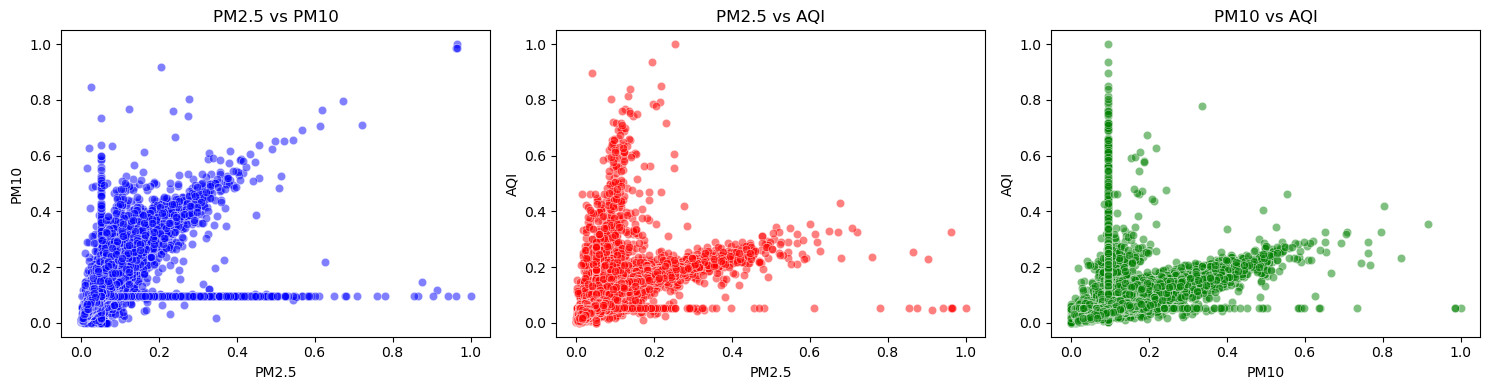

In [19]:
# ==============================
# 2️⃣ BIVARIATE ANALYSIS
# ==============================
print("===== BIVARIATE ANALYSIS =====\n")

# Select only numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# 📊 Correlation Matrix
corr_matrix = df[numeric_cols].corr()

# 🔍 Display correlation table
print("===== Bivariate Correlation Matrix =====")
print(corr_matrix.round(2))

# 🔁 Scatter Plots for Strong Correlations
# PM2.5 vs PM10, PM2.5 vs AQI, PM10 vs AQI
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='PM2.5', y='PM10', alpha=0.5, color='blue')
plt.title("PM2.5 vs PM10")

plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='PM2.5', y='AQI', alpha=0.5, color='red')
plt.title("PM2.5 vs AQI")

plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='PM10', y='AQI', alpha=0.5, color='green')
plt.title("PM10 vs AQI")

plt.tight_layout()
plt.show()



## 🌐 Multivariate Analysis

Multivariate analysis explores relationships among **three or more variables** simultaneously.

### Techniques Applied:
- **Correlation Matrix:** To identify linear relationships among pollutants.  
- **Heatmap Visualization:** To display the strength and direction of correlations.  
- **Time Series Trend:** To study pollution variation over months and years.

### Insights:
- Strong correlations among **PM2.5**, **PM10**, and **AQI** suggest they are the primary indicators of poor air quality.  
- Seasonal trends indicated **higher pollution during winter months**, likely due to weather stagnation and increased combustion activity.  
- Some gaseous pollutants (like SO2 and O3) showed weaker correlations, implying region-specific or meteorological influences.


===== MULTIVARIATE ANALYSIS =====



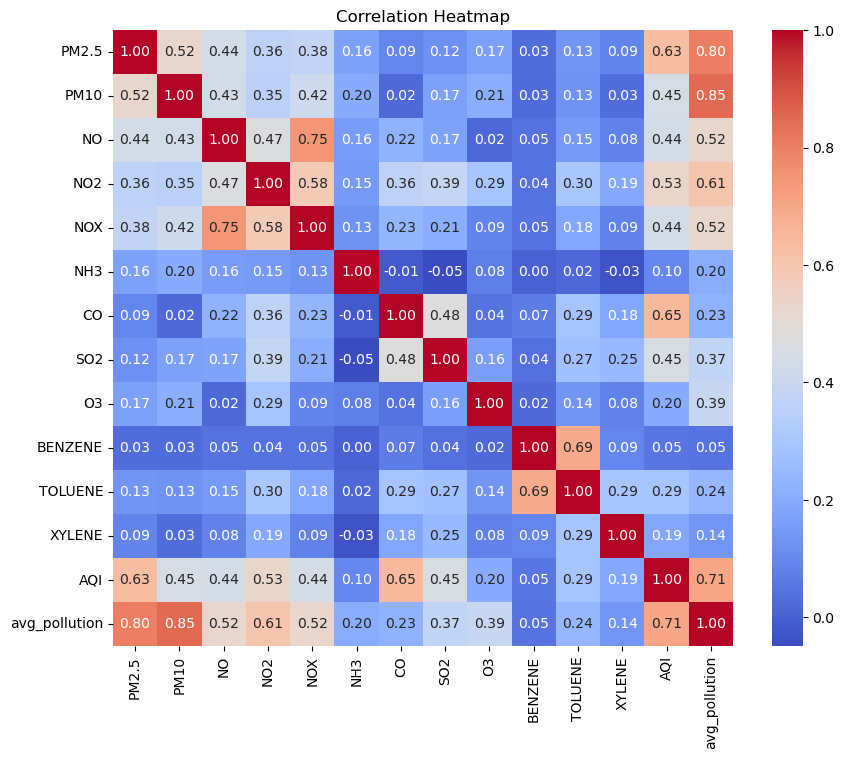

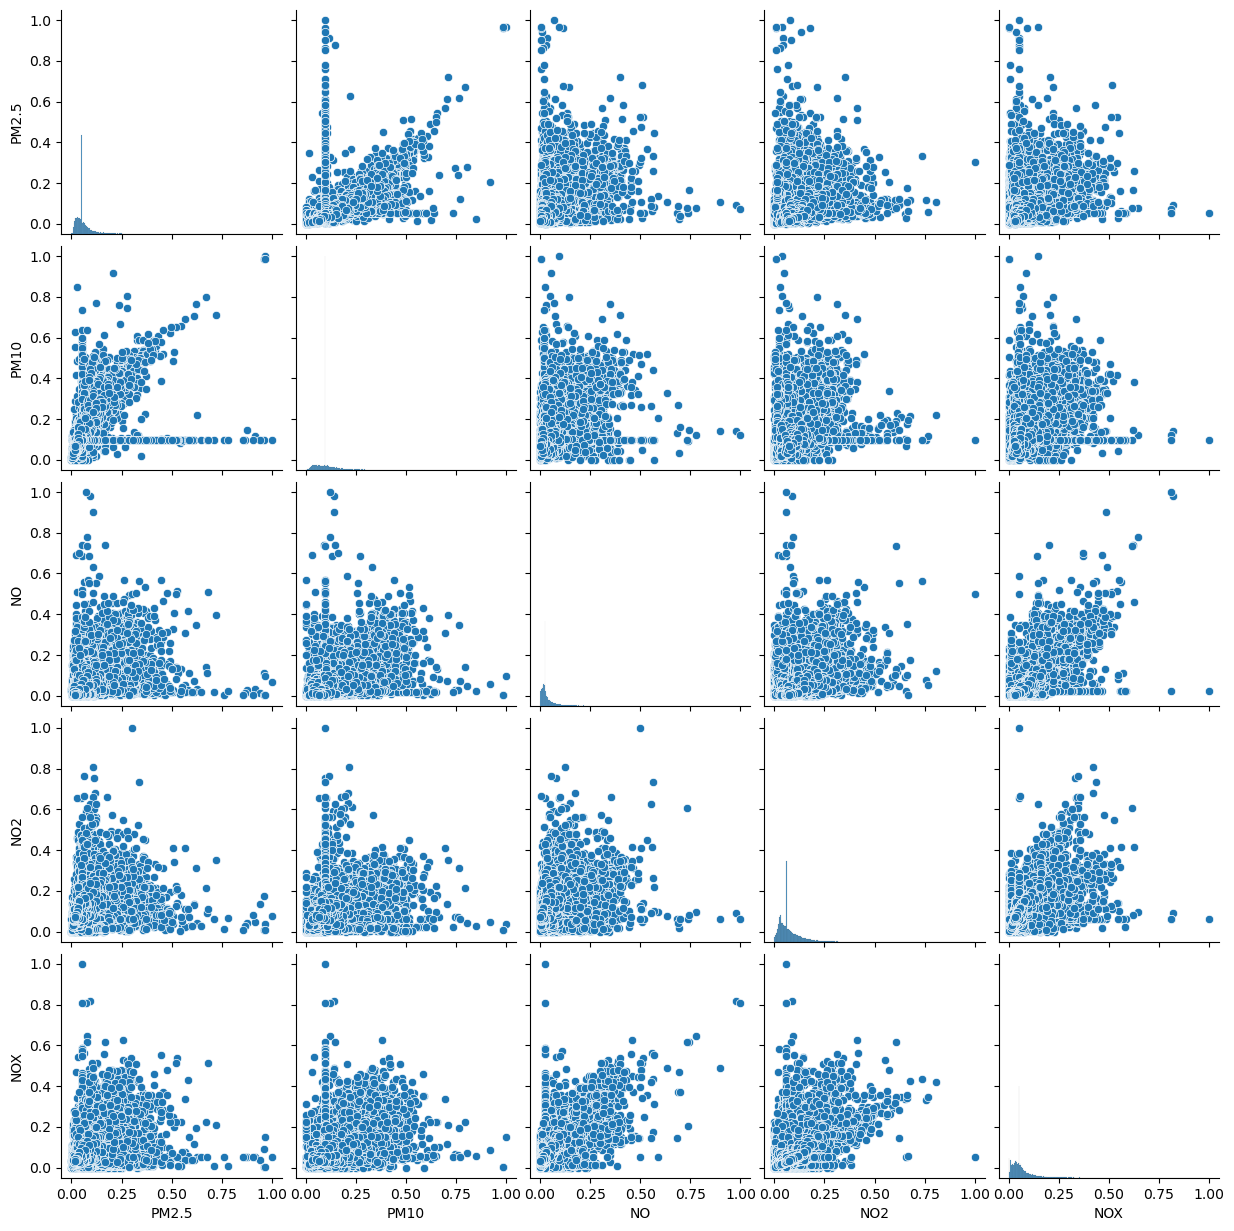


✅ Univariate, Bivariate, and Multivariate analysis completed.


In [20]:
# ==============================
# 3️⃣ MULTIVARIATE ANALYSIS
# ==============================
print("===== MULTIVARIATE ANALYSIS =====\n")

# Correlation matrix
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Pairplot for top numeric variables
sns.pairplot(df[numeric_cols[:5]])
plt.show()

# Pollution trend over time
if 'date' in df.columns and 'avg_pollution' in df.columns:
    plt.figure(figsize=(12,6))
    df.groupby('date')['avg_pollution'].mean().plot()
    plt.title("Average Pollution Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Avg Pollution")
    plt.show()

print("\n✅ Univariate, Bivariate, and Multivariate analysis completed.")




## 🧠 Summary & Insights

### ✅ Key Takeaways:
1. **PM10 and PM2.5** are the most critical contributors to overall air pollution.  
2. **AQI** closely aligns with particulate matter concentrations.  
3. Most Indian cities experience **Moderate to Poor** air quality levels throughout the year.  
4. Seasonal and regional factors strongly influence pollution patterns.

### 💡 Recommendations:
- Implement stricter **emission control measures** for industries and vehicles.  
- Increase **urban green cover** and promote **public transport** usage.  
- Conduct **long-term monitoring** integrating meteorological parameters for predictive modeling.

---

### 📈 Conclusion

Through this analysis, it becomes evident that improving air quality requires multi-dimensional efforts involving:  
- Cleaner energy sources  
- Better waste management  
- Policy interventions and citizen participation  

This study demonstrates how **data-driven analysis** can guide sustainable environmental decisions.
